In [33]:
import pandas as pd

accounts = pd.read_csv('da_fitly_account_info (1).csv')
customer_support= pd.read_csv('da_fitly_customer_support.csv')
user_activity = pd.read_csv('da_fitly_user_activity.csv')

print(accounts.info())
print(customer_support.info())
print(user_activity.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_time_hours  918 non-null    float64
 5   state  

In [34]:
import pandas as pd

#data cleaning 
customer_support['ticket_time'] = pd.to_datetime(customer_support['ticket_time'], format='%Y-%m-%d %H:%M:%S.%f')
customer_support['user_id'] = customer_support['user_id'].astype(int)
customer_support['channel'] = customer_support['channel'].str.lower().str.strip()
customer_support['channel'] = customer_support['channel'].replace('-', 'unknown')
user_activity['user_id'] = user_activity['user_id'].astype(int)
user_activity['event_time'] = pd.to_datetime(user_activity['event_time'])


In [35]:
print(accounts.info())
print(customer_support.info())
print(user_activity.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ticket_time            918 non-null    datetime64[ns]
 1   user_id                918 non-null    int64         
 2   channel                918 non-null    object        
 3   topic                  918 non-null    object        
 4   resolution_time_h

In [36]:
# Force string, strip whitespace
accounts['customer_id'] = accounts['customer_id'].astype(str).str.strip()

# Remove leading C using regex (most robust)
accounts['customer_id_num'] = (
    accounts['customer_id'].str.replace(r'^C', '', regex=True).astype(int)
)


In [37]:
accounts[['customer_id', 'customer_id_num']].head(10)

,customer_id,customer_id_num
0,C10000,10000
1,C10001,10001
2,C10002,10002
3,C10003,10003
4,C10004,10004
5,C10005,10005
6,C10006,10006
7,C10007,10007
8,C10008,10008
9,C10009,10009


In [38]:
accounts.head()

,customer_id,email,state,plan,plan_list_price,churn_status,customer_id_num
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y,10000
1,C10001,user10001@example.net,Louisiana,Basic,22,Y,10001
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN,10002
3,C10003,user10003@example.com,Michigan,Free,0,NaN,10003
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN,10004


In [39]:
accounts.drop(columns=['customer_id'], inplace=True)
accounts.rename(columns={'customer_id_num': 'customer_id'}, inplace=True)

In [40]:
accounts.head()

,email,state,plan,plan_list_price,churn_status,customer_id
0,user10000@example.com,New Jersey,Enterprise,105,Y,10000
1,user10001@example.net,Louisiana,Basic,22,Y,10001
2,user10002@example.net,Oklahoma,Basic,24,NaN,10002
3,user10003@example.com,Michigan,Free,0,NaN,10003
4,user10004@example.com,Texas,Enterprise,119,NaN,10004


In [41]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   email            400 non-null    object
 1   state            400 non-null    object
 2   plan             400 non-null    object
 3   plan_list_price  400 non-null    int64 
 4   churn_status     114 non-null    object
 5   customer_id      400 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 18.9+ KB


In [42]:
accounts['churn_status'] = (accounts['churn_status'].replace({'Y': 'Yes, Churned', 'Yes': 'Yes, Churned'}).fillna('Not Churned'))
accounts['churn_status'] = accounts['churn_status'].astype('category')
accounts['churn_status'].unique()
accounts['churn_status'].value_counts()

churn_status
Not Churned     286
Yes, Churned    114
Name: count, dtype: int64

In [43]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   email            400 non-null    object  
 1   state            400 non-null    object  
 2   plan             400 non-null    object  
 3   plan_list_price  400 non-null    int64   
 4   churn_status     400 non-null    category
 5   customer_id      400 non-null    int64   
dtypes: category(1), int64(2), object(3)
memory usage: 16.3+ KB


In [44]:
accounts.head(20)

,email,state,plan,plan_list_price,churn_status,customer_id
0,user10000@example.com,New Jersey,Enterprise,105,"Yes, Churned",10000
1,user10001@example.net,Louisiana,Basic,22,"Yes, Churned",10001
2,user10002@example.net,Oklahoma,Basic,24,Not Churned,10002
3,user10003@example.com,Michigan,Free,0,Not Churned,10003
4,user10004@example.com,Texas,Enterprise,119,Not Churned,10004
5,user10005@example.org,Ohio,Enterprise,114,Not Churned,10005
6,user10006@example.com,Kentucky,Basic,19,Not Churned,10006
7,user10007@example.com,North Carolina,Basic,10,"Yes, Churned",10007
8,user10008@example.net,Alaska,Enterprise,87,Not Churned,10008
9,user10009@example.com,Virginia,Free,0,Not Churned,10009


In [73]:
#create a churn_flag column

accounts['churn_flag'] = accounts['churn_status'].apply( lambda x: 1 if x == 'Yes, Churned' else 0)
# Convert churn_flag to numeric type explicitly
accounts['churn_flag'] = pd.to_numeric(accounts['churn_flag'])
accounts.head(5)

,email,state,plan,plan_list_price,churn_status,customer_id,churn_flag
0,user10000@example.com,New Jersey,Enterprise,105,"Yes, Churned",10000,1
1,user10001@example.net,Louisiana,Basic,22,"Yes, Churned",10001,1
2,user10002@example.net,Oklahoma,Basic,24,Not Churned,10002,0
3,user10003@example.com,Michigan,Free,0,Not Churned,10003,0
4,user10004@example.com,Texas,Enterprise,119,Not Churned,10004,0


In [74]:
#how active each user is: User engagement
engagement_agg = (user_activity.groupby('user_id').agg(
        total_events=('event_type', 'count'),
        unique_event_types=('event_type', 'nunique')).reset_index())
print(engagement_agg)

     user_id  total_events  unique_event_types
0      10000             3                   2
1      10001             1                   1
2      10002             1                   1
3      10003             1                   1
4      10004             4                   2
..       ...           ...                 ...
241    10392             2                   1
242    10393             3                   2
243    10394             1                   1
244    10395             2                   2
245    10396             2                   1

[246 rows x 3 columns]


In [75]:
support_agg = (
    customer_support
    .groupby('user_id')
    .agg(
        total_tickets=('ticket_time', 'count'),
        avg_resolution_time=('resolution_time_hours', 'mean'),
        resolved_tickets=('state', 'sum')  # 1 = resolved
    ).reset_index()
)

support_agg['avg_resolution_time'] = support_agg['avg_resolution_time'].round(2)
support_agg['resolved_tickets'] = support_agg['resolved_tickets'].round(0)

print(support_agg)

     user_id  total_tickets  avg_resolution_time  resolved_tickets
0      10000              3                21.45                 2
1      10001              4                17.54                 3
2      10002              3                 6.43                 2
3      10003              1                 2.19                 1
4      10004              4                 8.54                 2
..       ...            ...                  ...               ...
362    10394              3                19.17                 2
363    10395              3                 4.05                 2
364    10397              5                18.72                 2
365    10398              2                 3.64                 2
366    10399              1                 4.46                 0

[367 rows x 4 columns]


In [76]:
#Merge Engagement + Support
engagement_support = engagement_agg.merge(support_agg, on='user_id', how='left')

engagement_support[['total_tickets', 'avg_resolution_time', 'resolved_tickets']] = (engagement_support[['total_tickets', 'avg_resolution_time', 'resolved_tickets']].fillna(0))
engagement_support[['total_tickets', 'resolved_tickets']] = (engagement_support[['total_tickets', 'resolved_tickets']]
    .round(0)
    .astype(int)
)

print(engagement_support)

     user_id  total_events  unique_event_types  total_tickets  \
0      10000             3                   2              3   
1      10001             1                   1              4   
2      10002             1                   1              3   
3      10003             1                   1              1   
4      10004             4                   2              4   
..       ...           ...                 ...            ...   
241    10392             2                   1              2   
242    10393             3                   2              3   
243    10394             1                   1              3   
244    10395             2                   2              3   
245    10396             2                   1              0   

     avg_resolution_time  resolved_tickets  
0                  21.45                 2  
1                  17.54                 3  
2                   6.43                 2  
3                   2.19               

In [77]:
#merge with accounts information to analyze churn

final_df = accounts.merge(engagement_support, left_on='customer_id', right_on='user_id', how='left') #merging the table;
final_df.drop(columns=['user_id'], inplace=True)  #drops duplicates, user_id and customer_id is the same, so we drop one, and update the dataframe..
final_df[['total_events', 'unique_event_types']] = (final_df[['total_events', 'unique_event_types']].fillna(0)) # cleans missing values in the engagement columns

support_cols = ['total_tickets', 'avg_resolution_time', 'resolved_tickets']

final_df[support_cols] = final_df[support_cols].fillna(0) 
final_df.head(10)

,email,state,plan,plan_list_price,churn_status,customer_id,churn_flag,total_events,unique_event_types,total_tickets,avg_resolution_time,resolved_tickets
0,user10000@example.com,New Jersey,Enterprise,105,"Yes, Churned",10000,1,3.0,2.0,3.0,21.45,2.0
1,user10001@example.net,Louisiana,Basic,22,"Yes, Churned",10001,1,1.0,1.0,4.0,17.54,3.0
2,user10002@example.net,Oklahoma,Basic,24,Not Churned,10002,0,1.0,1.0,3.0,6.43,2.0
3,user10003@example.com,Michigan,Free,0,Not Churned,10003,0,1.0,1.0,1.0,2.19,1.0
4,user10004@example.com,Texas,Enterprise,119,Not Churned,10004,0,4.0,2.0,4.0,8.54,2.0
5,user10005@example.org,Ohio,Enterprise,114,Not Churned,10005,0,1.0,1.0,2.0,7.82,0.0
6,user10006@example.com,Kentucky,Basic,19,Not Churned,10006,0,0.0,0.0,0.0,0.00,0.0
7,user10007@example.com,North Carolina,Basic,10,"Yes, Churned",10007,1,0.0,0.0,0.0,0.00,0.0
8,user10008@example.net,Alaska,Enterprise,87,Not Churned,10008,0,2.0,2.0,1.0,4.58,1.0
9,user10009@example.com,Virginia,Free,0,Not Churned,10009,0,4.0,3.0,3.0,8.27,1.0


In [85]:
final_df['total_tickets'].sum()

np.float64(548.0)

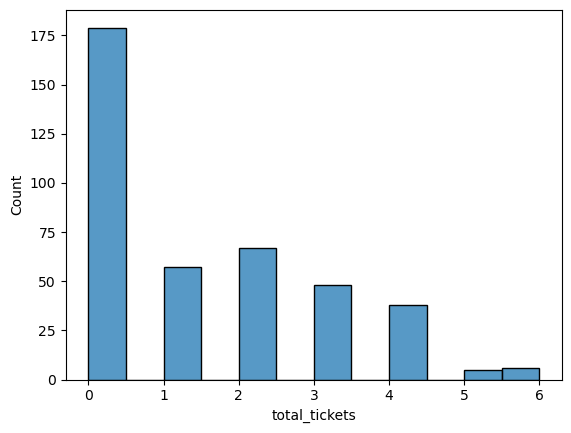

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data = final_df, x='total_tickets')
plt.show()


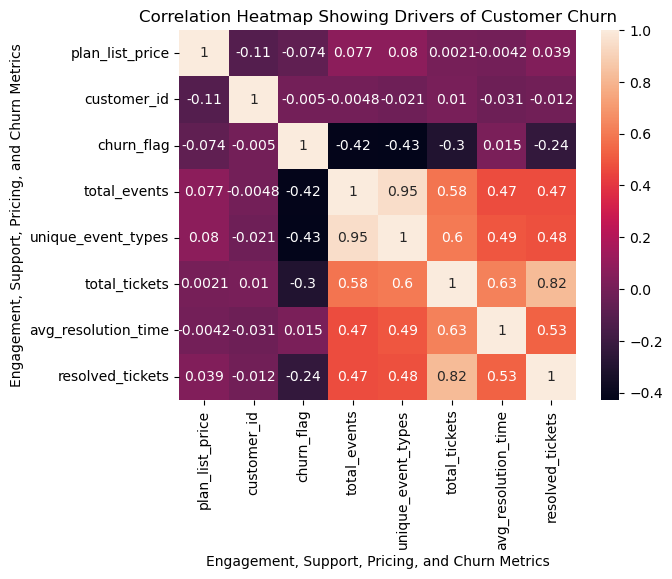

In [107]:
sns.heatmap(final_df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap Showing Drivers of Customer Churn')
plt.xlabel('Engagement, Support, Pricing, and Churn Metrics')
plt.ylabel('Engagement, Support, Pricing, and Churn Metrics')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(x='total_events', y='total_tickets',  data= final_df, kind='scatter' ,col= 'plan')
plt.xscale('log')
plt.show()

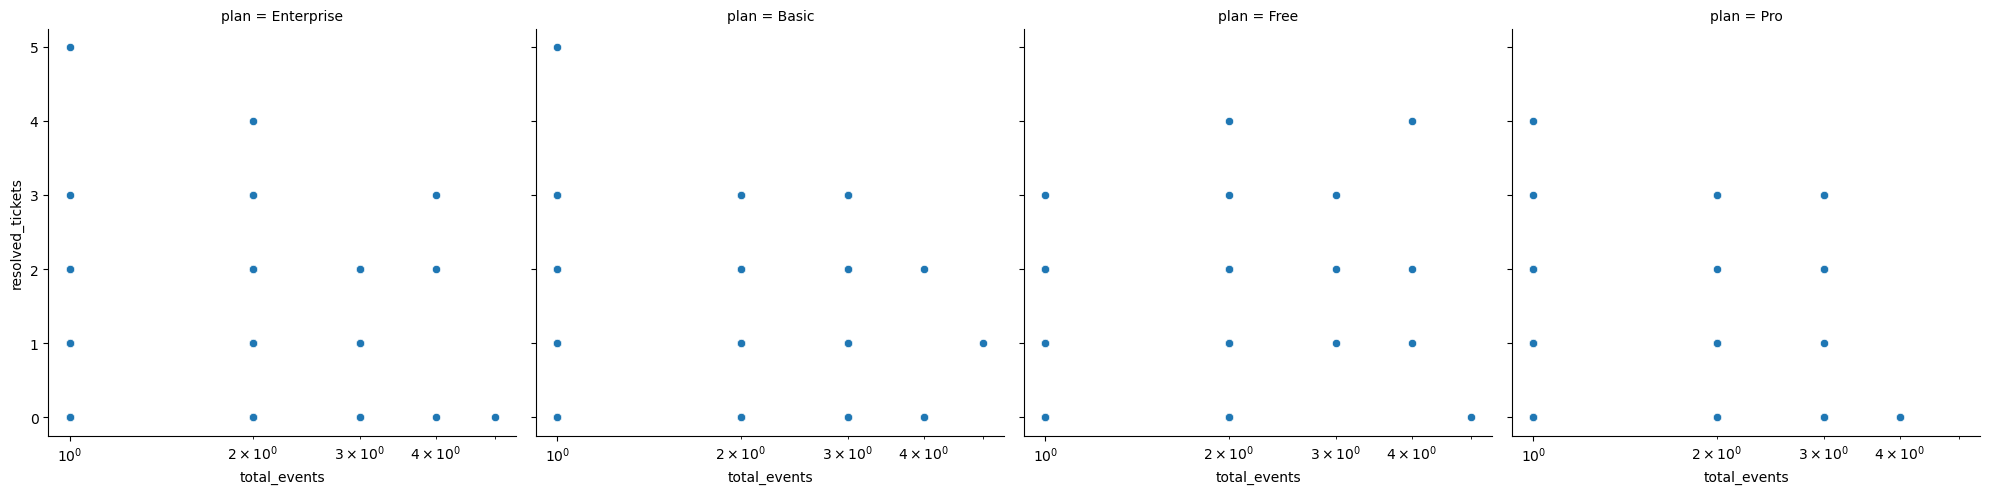

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(x='total_events', y='resolved_tickets',  data= final_df, kind='scatter' ,col= 'plan')
plt.xscale('log')
plt.show()

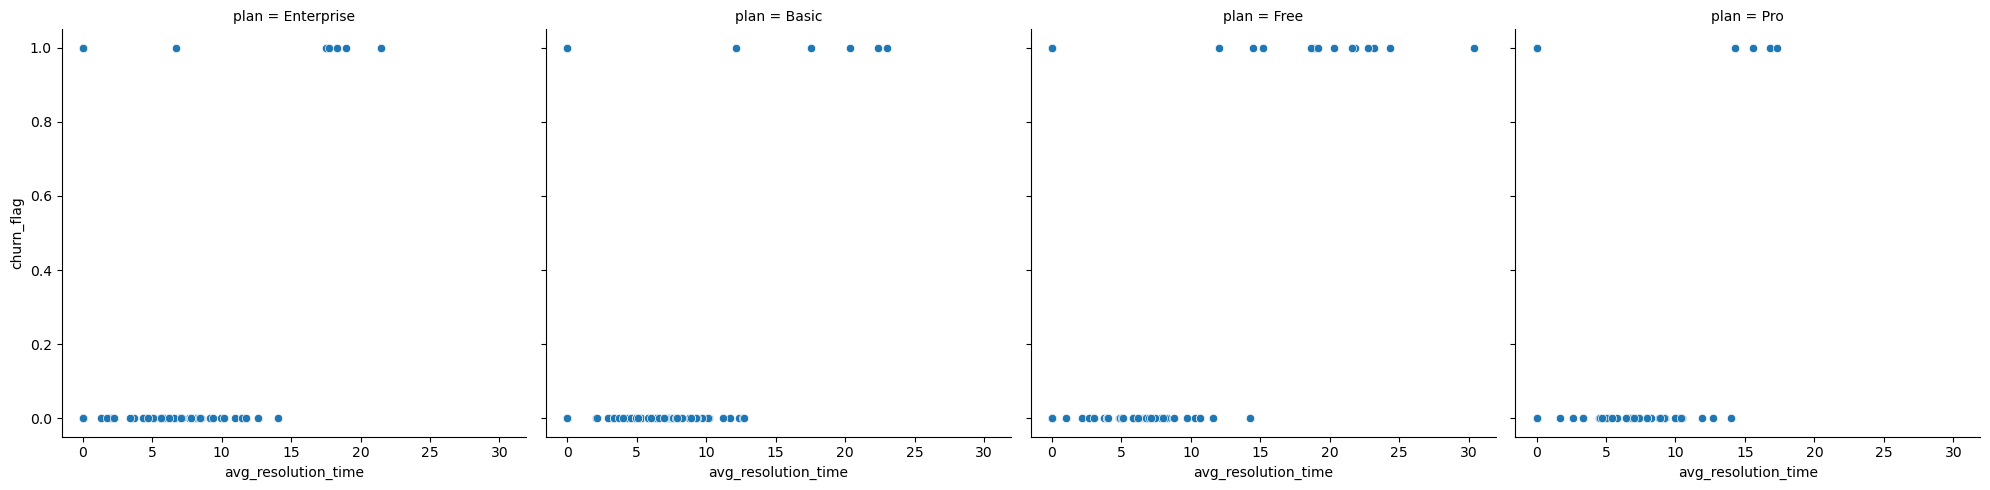

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(x='avg_resolution_time', y='churn_flag',  data= final_df, kind='scatter' ,col= 'plan')
plt.show()

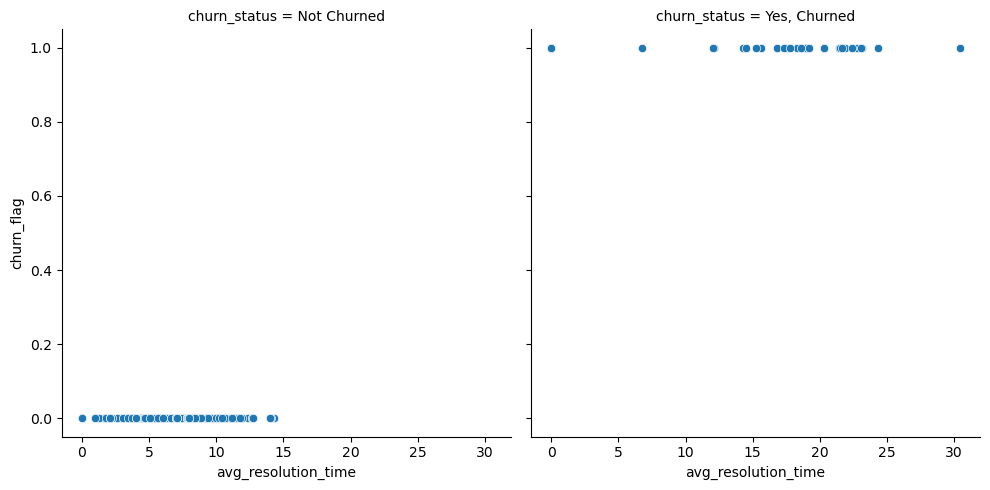

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(x='avg_resolution_time', y='churn_flag',  data= final_df, kind='scatter' ,col= 'churn_status')
plt.show()

REQUIRED VISUALIZATIONS

## Churn Baseline 

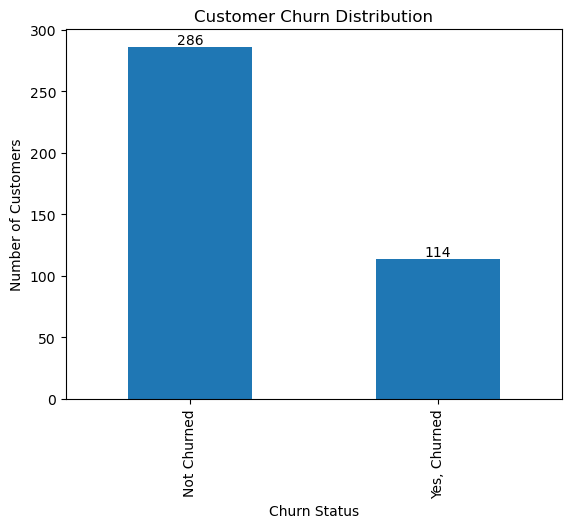

In [49]:
#Single Variable: Churn Distribution

import matplotlib.pyplot as plt

ax= final_df['churn_status'].value_counts().plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

#The chart shows that a significant portion of customers have churned, confirming churn is a material business issue.

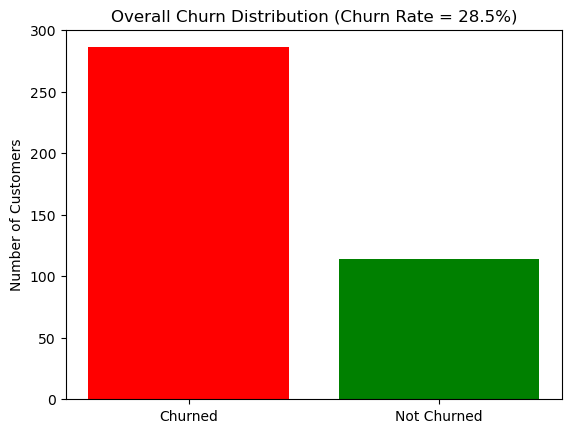

In [50]:
#create a churn flag 
final_df['churn_flag'] = final_df['churn_status'].apply( lambda x: 1 if x == 'Yes, Churned' else 0)

# Convert churn_flag to numeric type explicitly
final_df['churn_flag'] = pd.to_numeric(final_df['churn_flag'])

# visualize 
churn_rate = final_df['churn_flag'].mean()

plt.figure()
plt.bar(['Churned', 'Not Churned'],
        final_df['churn_status'].value_counts().values,
       color=['red', 'green'])
plt.title(f'Overall Churn Distribution (Churn Rate = {churn_rate:.1%})')
plt.ylabel('Number of Customers')
plt.show()



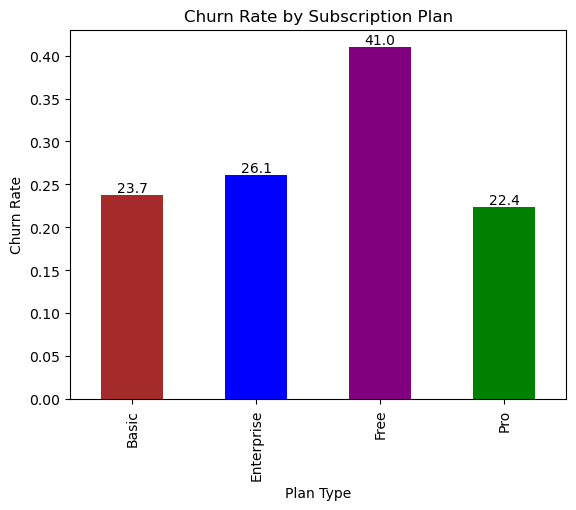

In [51]:
#Churn Rate by Plan (Multi-variable)

churn_by_plan = final_df.groupby('plan')['churn_flag'].mean()

plt.figure()
colors = ['brown', 'blue', 'purple', 'green']
ax = churn_by_plan.plot(kind='bar', color= colors)
plt.title('Churn Rate by Subscription Plan')
plt.ylabel('Churn Rate')
plt.xlabel('Plan Type')

# Add bar labels
for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height() * 100:.1f}',   # convert to percentage
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )


plt.show()

#Free plan is more prone to churn.Pro plan users have a lower rate of churning.

Combining the churn rates of basic, enterprise, and pro subscribers, this equates to 70% of paid subscribers who left in the last two quarters.

## Churn Rate by States - Segmentation by customer demongraphics (Location)

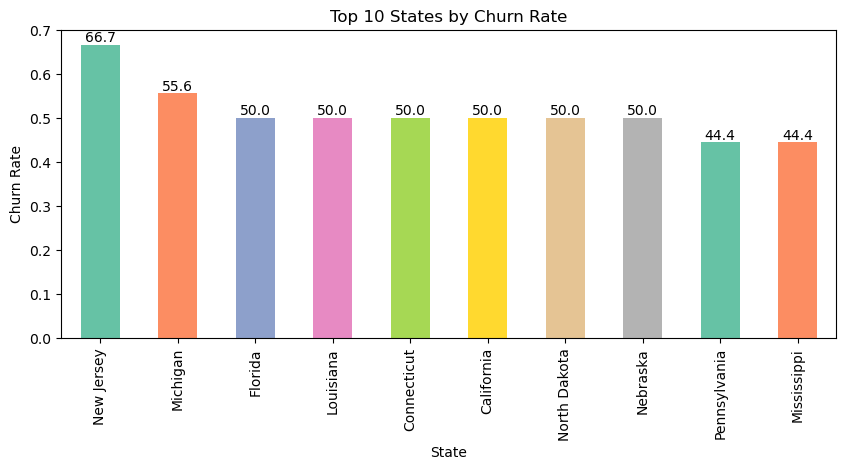

In [55]:
# Convert churn_flag to numeric type explicitly
final_df['churn_flag'] = pd.to_numeric(final_df['churn_flag'])

#Churn Rate by State (Multi-variable)
churn_by_state = (final_df.groupby('state')['churn_flag'].mean().sort_values(ascending=False))

plt.figure(figsize=(10,4))
ax = churn_by_state.head(10).plot(kind='bar', color=plt.cm.Set2.colors)
plt.title('Top 10 States by Churn Rate')
plt.ylabel('Churn Rate')
plt.xlabel('State')

# Add bar labels
for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height() * 100:.1f}',   # convert to percentage
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()


NOTES

New Jersey, Michigan, and Nebraska show disproportionately higher churn rate, which may indicate regional differences in user needs or marketing alignment.

## Churn Rate by Plan List Price (Price Bands)

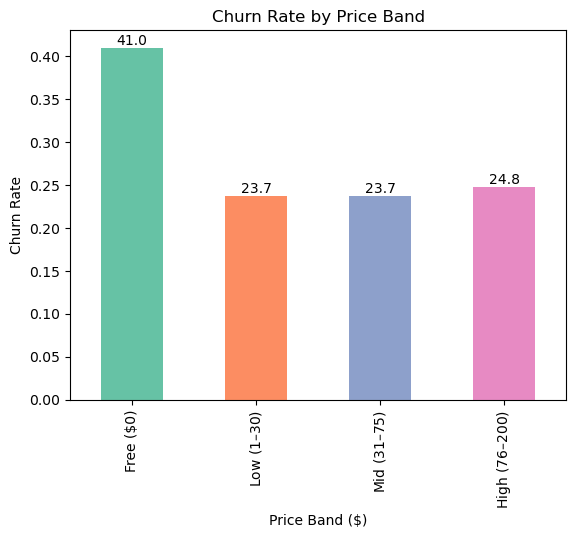

In [70]:
#Does price level affect churn 

#creating price bins
final_df['price_band'] = pd.cut(
    final_df['plan_list_price'],
    bins=[-1, 0, 30, 75, 200],
    labels=[
        'Free ($0)',
        'Low ($1–$30)',
        'Mid ($31–$75)',
        'High ($76–$200)']
)


#visualize 
churn_by_price = final_df.groupby('price_band', observed=True)['churn_flag'].mean()

plt.figure()
ax=churn_by_price.plot(kind='bar', color=plt.cm.Set2.colors)
plt.title('Churn Rate by Price Band')
plt.ylabel('Churn Rate')
plt.xlabel('Price Band ($)')

# Add bar labels
for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height() * 100:.1f}',   # convert to percentage
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )


plt.show()


***Lower-priced plans experience significantly higher churn than higher-priced plans.***


## Churn by Customer Activity (Low vs High Usage)

****Does engagement protect against churn?****

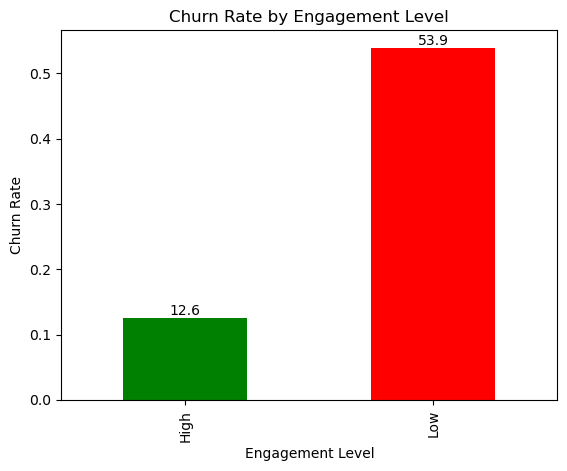

In [57]:
#get the average engagement per user
median_engagement = final_df['total_events'].median()

#classify by engagement clases 
final_df['engagement_level'] = final_df['total_events'].apply(lambda x: 'Low' if x < median_engagement else 'High')

churn_by_engagement = (final_df.groupby('engagement_level')['churn_flag'].mean())

plt.figure()
colors = ['green', 'red']
ax=churn_by_engagement.plot(kind='bar', color=colors)
plt.title('Churn Rate by Engagement Level')
plt.ylabel('Churn Rate')
plt.xlabel('Engagement Level')

# Add bar labels
for bar in ax.patches:
    ax.annotate(
        f'{bar.get_height() * 100:.1f}',   # convert to percentage
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom'
    )
    
plt.show()


Low-engagement users churn at a much higher rate than highly engaged users. Users with low engagements have less user activity event type. Trying to engage customers will improve subscribers' retention rates.

## Engagement Analysis (Does Usage Drive Churn?)

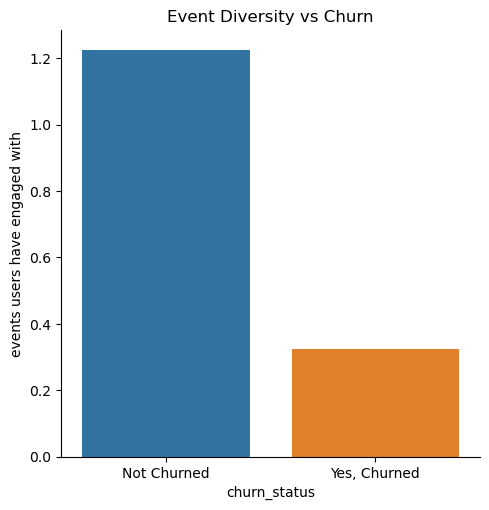

In [104]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.catplot(x='churn_status', y= 'unique_event_types', data = final_df, hue='churn_status', kind='bar', errorbar=None)
plt.title('Event Diversity vs Churn')
plt.xlabel('churn_status')
plt.ylabel('events users have engaged with')
plt.show()

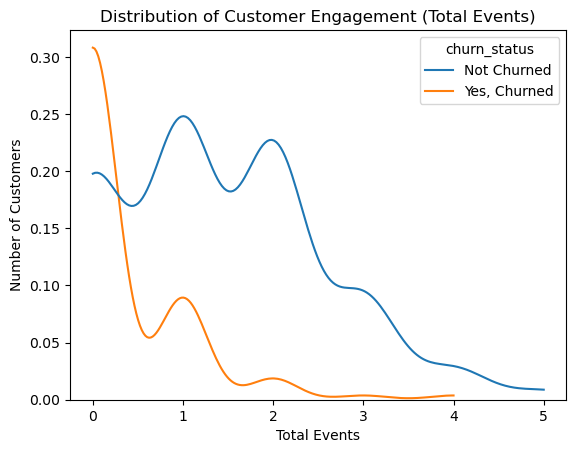

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.kdeplot(x='total_events', data = final_df, hue='churn_status', cut=0)
plt.title('Distribution of Customer Engagement (Total Events)')
plt.xlabel('Total Events')
plt.ylabel('Number of Customers')
plt.show()


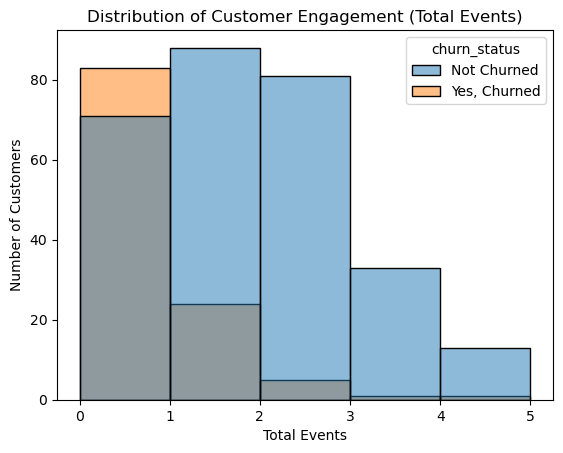

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(x='total_events', data = final_df, hue='churn_status', binwidth=1)
plt.title('Distribution of Customer Engagement (Total Events)')
plt.xlabel('Total Events')
plt.ylabel('Number of Customers')
plt.show()

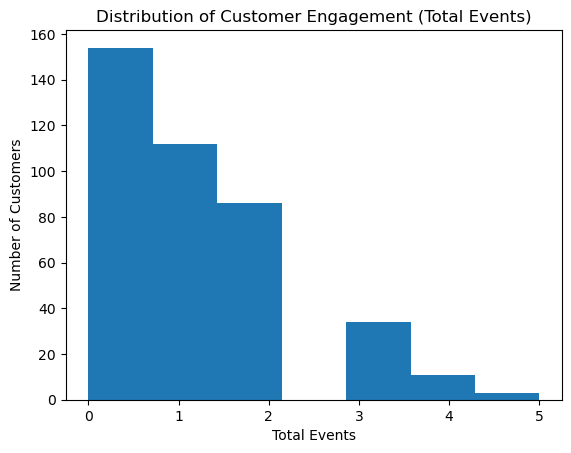

In [91]:
#What does a normal event looks like?
plt.figure()
plt.hist(final_df['total_events'], bins=7)
plt.title('Distribution of Customer Engagement (Total Events)')
plt.xlabel('Total Events')
plt.ylabel('Number of Customers')
plt.show()


Right-skewed = few power users, many light user.

## Engagement vs churn (two-variable analysis)

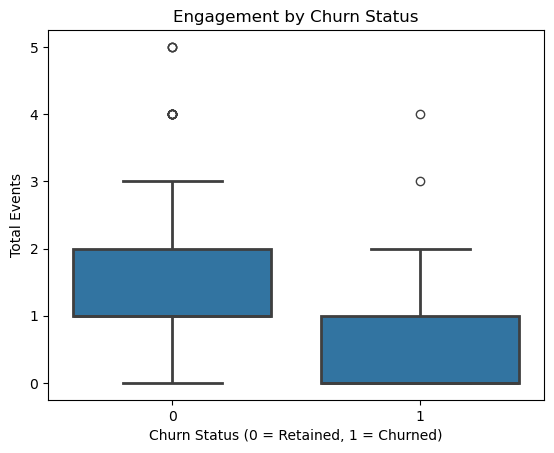

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(
    data=final_df,
    x='churn_flag',
    y='total_events',
    showfliers=True,          # show outliers
    linewidth=2, # makes quartile & median lines thicker
)

plt.title('Engagement by Churn Status')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Total Events')

plt.show()


Lower median for churned users = disengagement risk

Wide spread among retained users = healthy usage diversity

## Feature depth vs churn (optional but powerful)

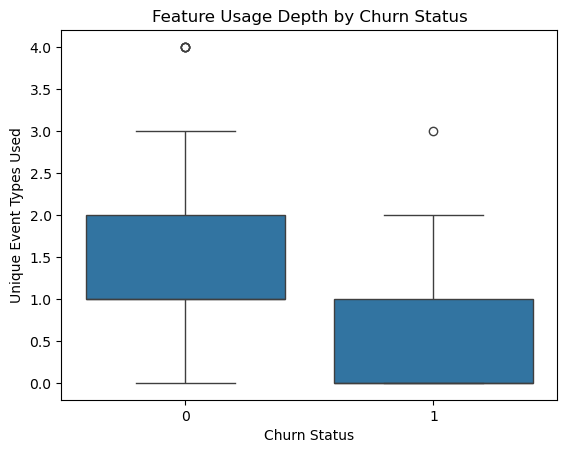

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure()
sns.boxplot(data=final_df, x='churn_flag', y='unique_event_types')
plt.title('Feature Usage Depth by Churn Status')
plt.suptitle('')
plt.xlabel('Churn Status')
plt.ylabel('Unique Event Types Used')
plt.show()


## Support load vs churn

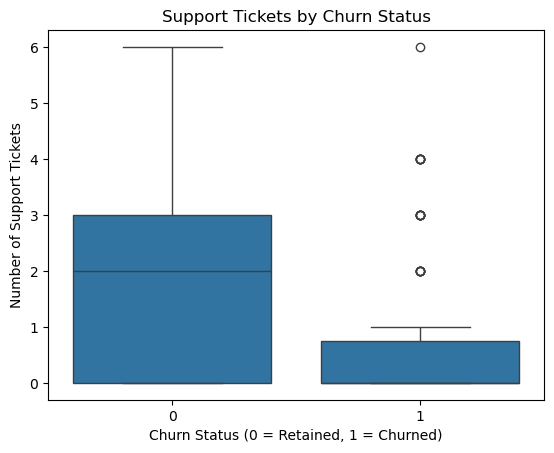

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt 


sns.boxplot(data = final_df, x='churn_flag', y='total_tickets')
plt.title('Support Tickets by Churn Status')
plt.suptitle('')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Support Tickets')
plt.show()

***Retained users actually contact support more frequently***

Median tickets for retained users (0) ≈ 2

Median tickets for churned users (1) ≈ 0

📌 This means:

Churned users are NOT contacting support more often than retained users.

This is an important and non-intuitive finding — and it’s totally okay.

2️⃣ Churned users mostly have zero or very few tickets

Most churned users sit at 0–1 tickets

A few churned users have high ticket counts (outliers), but they are rare

📌 This suggests:

Many churned users may be quiet churners

They leave without repeatedly reaching out for help

3️⃣ Retained users show a wider support interaction range

Retained users have more tickets, larger spread, higher maximums.

📌 Interpretation:

Retained users may experience issues but stay because support eventually helps them

## Resolution time vs churn

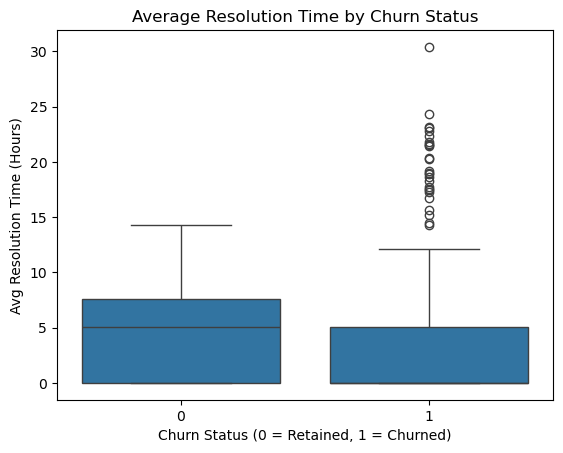

In [62]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.boxplot( data= final_df, x='churn_flag', y= 'avg_resolution_time')
plt.title('Average Resolution Time by Churn Status')
plt.suptitle('')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Avg Resolution Time (Hours)')
plt.show()



## Resolved vs unresolved support & churn

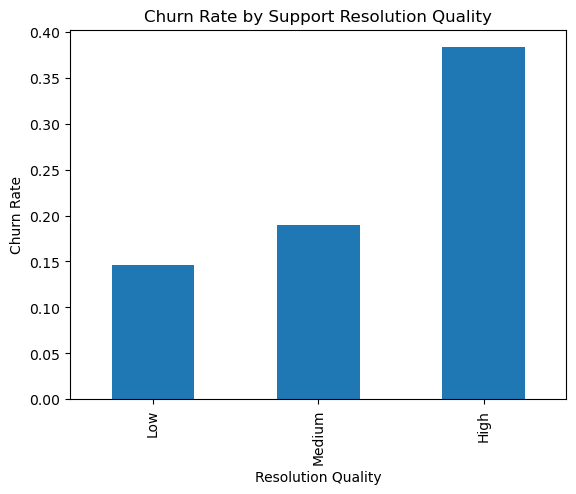

In [63]:
#create a resolution rate 
final_df['resolution_rate'] = (
    final_df['resolved_tickets'] / final_df['total_tickets']).fillna(1)  # users with no tickets assumed fully resolved

#bins for visualization
resolution_bins = pd.cut(
    final_df['resolution_rate'],
    bins=[0, 0.5, 0.8, 1.0],
    labels=['Low', 'Medium', 'High'])

churn_by_resolution = (
    final_df
    .groupby(resolution_bins, observed=True)['churn_flag']
    .mean())

plt.figure()
churn_by_resolution.plot(kind='bar')
plt.title('Churn Rate by Support Resolution Quality')
plt.ylabel('Churn Rate')
plt.xlabel('Resolution Quality')
plt.show()


## Support ↔ Engagement ↔ Churn (scatterplot)

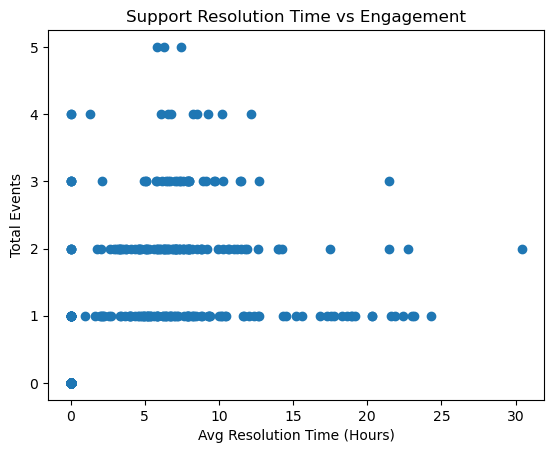

In [64]:
plt.figure()
plt.scatter(
    final_df['avg_resolution_time'],
    final_df['total_events']
)
plt.title('Support Resolution Time vs Engagement')
plt.xlabel('Avg Resolution Time (Hours)')
plt.ylabel('Total Events')
plt.show()


The relationship between support resolution time and engagement does not appear to be linear. While some users with longer resolution times show lower engagement, others remain moderately active, suggesting that resolution speed alone is not sufficient to explain disengagement.

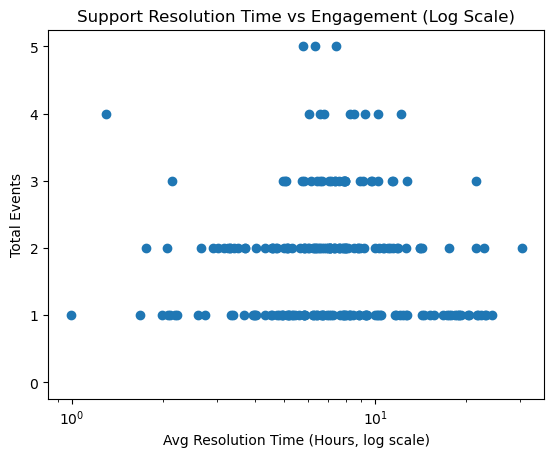

In [65]:
plt.figure()
plt.scatter(
    final_df['avg_resolution_time'],
    final_df['total_events']
)

plt.xscale('log')
plt.xlabel('Avg Resolution Time (Hours, log scale)')
plt.ylabel('Total Events')
plt.title('Support Resolution Time vs Engagement (Log Scale)')
plt.show()


## Event Diversity vs Churn 

<Figure size 640x480 with 0 Axes>

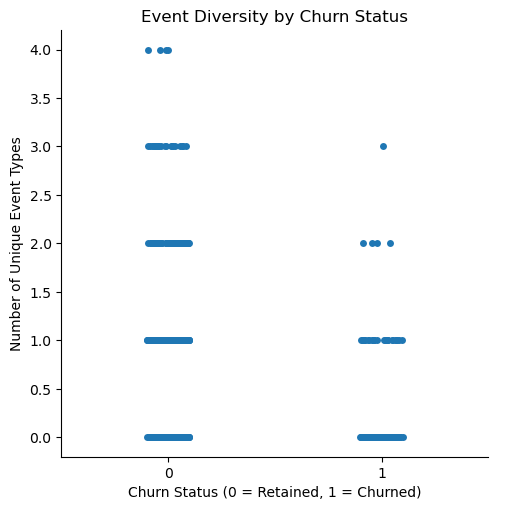

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure()
sns.catplot(data = final_df, x='churn_flag', y='unique_event_types')
plt.title('Event Diversity by Churn Status')
plt.suptitle('')
plt.xlabel('Churn Status (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Unique Event Types')
plt.show()


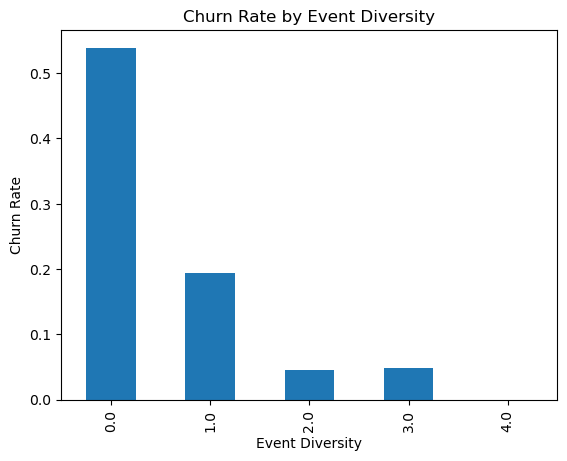

In [67]:
churn_by_diversity = (
    final_df
    .groupby('unique_event_types')['churn_flag']
    .mean()
)

churn_by_diversity.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.xlabel('Event Diversity')
plt.title('Churn Rate by Event Diversity')
plt.show()


In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt 


sns.relplot(data=final_df, x=

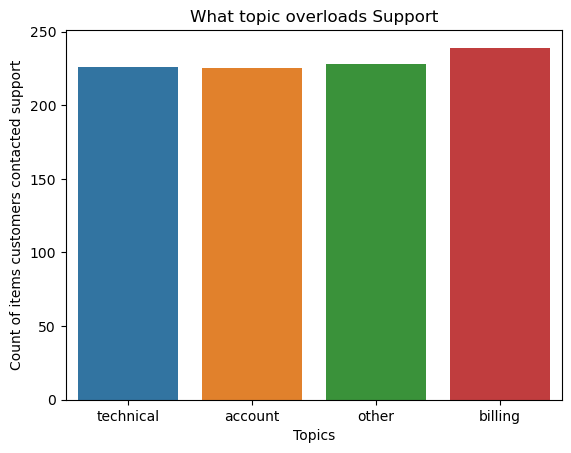

In [115]:
import seaborn as sns 
import matplotlib.pyplot as plt 

ax=sns.countplot(data=customer_support, x='topic', hue='topic')
plt.title('What topic overloads Support')
plt.xlabel('Topics')
plt.ylabel('Count of items customers contacted support')
plt.show()


## MEARGE TABLES

In [125]:
support_with_churn = customer_support.merge(
    final_df[['customer_id', 'churn_flag', 'churn_status']],
  left_on='user_id', right_on='customer_id',
    how='left'
)

support_with_churn = support_with_churn.drop(columns=['customer_id', 'comments'])

support_with_churn.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,churn_flag,churn_status
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,0,Not Churned
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,0,Not Churned
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,0,Not Churned
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,0,Not Churned
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,0,Not Churned


In [126]:
len(support_with_churn)

918

In [128]:
churn_by_topic = (
    support_with_churn
    .groupby('topic')['churn_flag']
    .mean().round(2)
    .reset_index()
    .sort_values(by='churn_flag', ascending=False)
)

churn_by_topic


,topic,churn_flag
1,billing,0.36
2,other,0.29
0,account,0.28
3,technical,0.28


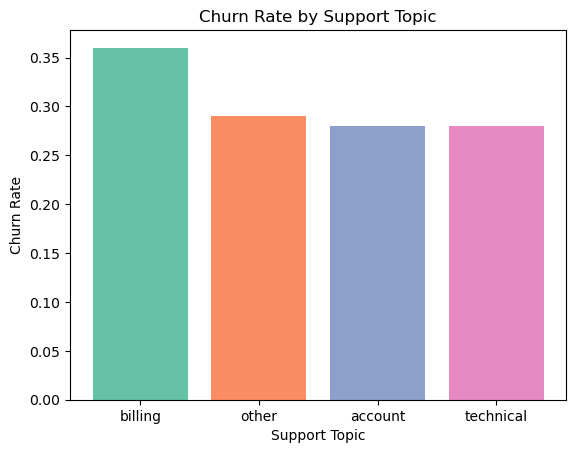

In [132]:
#Visualization
import matplotlib.pyplot as plt

plt.figure()
plt.bar(churn_by_topic['topic'], churn_by_topic['churn_flag'], color=plt.cm.Set2.colors)



plt.xlabel('Support Topic')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Support Topic')
plt.show()


## RESOLUTION TIME BY TOPIC AND CHURN

In [136]:
#Average Resolution time by Topic and Churn
resolution_by_topic_churn = (
    support_with_churn
    .groupby(['topic', 'churn_status'], observed=False)['resolution_time_hours']
    .mean()
    .reset_index()
)

resolution_by_topic_churn


,topic,churn_status,resolution_time_hours
0,account,Not Churned,6.729752
1,account,"Yes, Churned",18.776875
2,billing,Not Churned,6.110592
3,billing,"Yes, Churned",18.688391
4,other,Not Churned,6.931595
5,other,"Yes, Churned",18.485538
6,technical,Not Churned,7.221350
7,technical,"Yes, Churned",18.902698


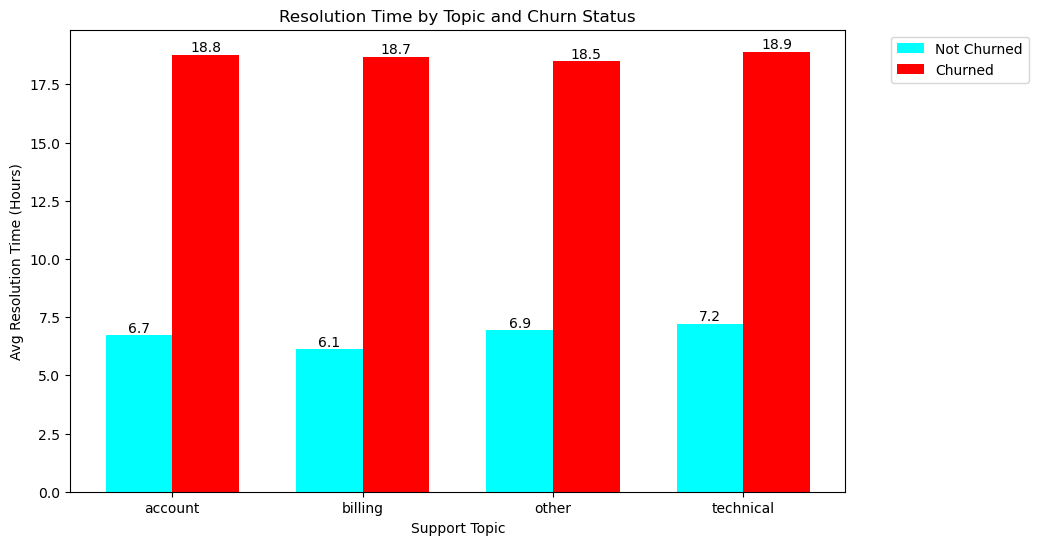

In [147]:
import numpy as np
import matplotlib.pyplot as plt

topics = resolution_by_topic_churn['topic'].unique()
x = np.arange(len(topics))
width = 0.35

not_churned = resolution_by_topic_churn[
    resolution_by_topic_churn['churn_status'] == 'Not Churned'
]['resolution_time_hours']

churned = resolution_by_topic_churn[
    resolution_by_topic_churn['churn_status'] == 'Yes, Churned'
]['resolution_time_hours']

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, not_churned, width, label='Not Churned', color='cyan')
bars2 = plt.bar(x + width/2, churned, width, label='Churned', color='red')

plt.xticks(x, topics)
plt.xlabel('Support Topic')
plt.ylabel('Avg Resolution Time (Hours)')
plt.title('Resolution Time by Topic and Churn Status')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 🔹 Add value labels
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        va='bottom'
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha='center',
        va='bottom'
    )

plt.show()
